# Response Elaboration in Open-Ended Attitude Answers

Exploratory extension to the confirmatory analysis in `03b`. Participants
wrote a free-text justification of their policy attitude before and after
the information period. This script asks what encouragement did to those
answers: whether people answered at all, how much they wrote, and which
aspects of the issue they raised.

The analysis is **not pre-specified and carries no hypotheses**. It is
reported as exploratory throughout, and the two levels are kept apart
because they differ in what they can carry:

| Level | Measures | Status |
|---|---|---|
| Participation and elaboration | Response rate, word count | Robust; model-free measures |
| Aspect focus | Zero-shot aspect assignment, pre/post shift | Exploratory; conditional on the validation in Part 7 |

No aspect result is reported before the classifier has been validated
against manual coding. If validation fails, Parts 8 and 9 are reported as a
measurement exercise rather than as findings.

## Data sources

Everything except the raw text comes from the analysis dataset written by
`03a`. Treatment coding, covariates, habitual-quality groups, and the
sample are therefore identical to the confirmatory models, and no variable
is constructed twice.

| Source | Contributes |
|---|---|
| `analysis_data_wave1.csv`, `analysis_data_wave3.csv` | Sample, treatment, covariates, uptake, quality, habitual groups |
| `df1_final_ac.csv`, `df3_final_ac.csv` | The four open-text fields only |

## Waves

T1 (basic child support) and T3 (cannabis legalisation) only. T2
(renewable-energy transition) is excluded because the open-text field is
incomplete in the current export; the exclusion belongs in the limitations,
and the topic comparison therefore runs over two issues rather than three.

## Outputs

| File | Content |
|---|---|
| `tab_response_rates` | Response rate by wave, arm, and topic |
| `tab_participation_model` | Logit of answering on treatment and covariates |
| `tab_elaboration` | Paired word-count change, by topic |
| `tab_elaboration_by_arm` | Word-count change by arm — the central result |
| `tab_elaboration_model` | OLS of word-count change on treatment and covariates |
| `tab_elaboration_uptake` | Elaboration among participants who actually searched |
| `tab_substantive_sensitivity` | Results with and without the low-information filter |
| `tab_threshold_sensitivity` | Aspect assignment at three score thresholds |
| `tab_aspect_shifts`, `tab_aspect_by_arm` | Pre/post shifts and their association with arm |
| `fig_*.png` | Distributions and shift plots |

## Design choices

| Choice | Rule | Reason |
|---|---|---|
| Sample | Defined by the analysis dataset | Elaboration and attitude results must describe the same participants |
| Primary outcome | Paired word-count change | Model-free; does not depend on the classifier |
| Paired subsample | Answered in both waves | Answering is itself treatment-affected; quantified in Part 4 |
| Covariates | Table 3.1, as merged from `03a` | Comparable to the confirmatory models |
| Aspect threshold | 0.50, with 0.40 and 0.60 as sensitivity | An arbitrary cut must be shown not to drive the result |
| Non-converged models | Excluded and counted | Reporting only the models that converged selects on the outcome |

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import ttest_rel, chi2_contingency
from statsmodels.stats.multitest import multipletests

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

## Part 1: Configuration

In [2]:
PROJECT_ROOT = os.path.expanduser("~/Desktop/GitHub/DoesMediaQualityMatter")
DATA_DIR = os.path.expanduser("~/Desktop/Masterarbeit/Data")

ANALYSIS_DIR = os.path.join(PROJECT_ROOT, "Output", "03_analysis_data")
OUT_DIR = os.path.join(PROJECT_ROOT, "Output", "04_open_responses")
TAB_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
for d in (OUT_DIR, TAB_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

ANALYSIS_FILES = {
    "Child support": os.path.join(ANALYSIS_DIR, "analysis_data_wave1.csv"),
    "Cannabis": os.path.join(ANALYSIS_DIR, "analysis_data_wave3.csv"),
}
TEXT_FILES = {
    "Child support": os.path.join(DATA_DIR, "df1_final_ac.csv"),
    "Cannabis": os.path.join(DATA_DIR, "df3_final_ac.csv"),
}

OPEN_PRE, OPEN_POST = "attitude_1_open_pre", "attitude_1_open_post"
NONE_PRE, NONE_POST = "attitude_1_none_pre", "attitude_1_none_post"

# The T3 export names the post-wave open fields differently.
RENAMES = {
    "Cannabis": {
        "open_attitude_1_post": OPEN_POST,
        "open_attitude_1none_post": NONE_POST,
    },
}

# Table 3.1, already harmonised by 03a, so no renaming is needed here.
COVARS = ["att_baseline", "prior_engagement", "polknow_total",
          "pol_interest_general", "newsuse_online", "edu_time", "age", "gender_f"]

ANALYSIS_VARS = ["pid", "group_f", "t_verbal", "t_money", "y_abs", "y_signed",
                 "exp_topic_uptake_yn", "effort_count", "q_primary",
                 "hab_overall_level_group", "hab_news_level_group",
                 "hab_news_corrected_level_group"] + COVARS

ARM_ORDER = ["control", "verbal", "monetary"]
ARM_LABELS = {"control": "Control", "verbal": "Verbal", "monetary": "Monetary"}

ZS_MODEL = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
ZS_THRESHOLDS = [0.40, 0.50, 0.60]
ZS_PRIMARY = 0.50

RANDOM_STATE = 20260912

## Part 2: Helpers

Two text helpers and one LaTeX writer matching the table style used
throughout the thesis.

In [3]:
def clean_text(text):
    """Lowercase, strip URLs, punctuation and digits; keep German umlauts."""
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-zäöüß\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def word_count(text):
    """Count words on the raw string, so counts reflect what participants wrote."""
    if pd.isna(text):
        return 0
    return len(str(text).split())


def write_latex_table(df, name, digits=3, caption=None):
    """Thesis table style: hline above, below the header and at the end;
    header row and first column in italics."""
    def esc(x):
        return re.sub(r"([_%&#])", r"\\\1", str(x))

    body = df.copy()
    for c in body.columns:
        if pd.api.types.is_numeric_dtype(body[c]):
            body[c] = body[c].map(lambda v: "--" if pd.isna(v) else f"{v:.{digits}f}")
    body = body.fillna("--").astype(str).map(esc)

    header = " & ".join(f"\\textit{{{esc(c)}}}" for c in df.columns)
    rows = ["      \\textit{" + r.iloc[0] + "} & " + " & ".join(r.iloc[1:]) + " \\\\"
            for _, r in body.iterrows()]
    lines = (([f"% {caption}"] if caption else [])
             + ["\\begin{tabular}{" + " ".join(["c"] * df.shape[1]) + "}",
                "      \\hline", "      " + header + " \\\\", "      \\hline"]
             + rows + ["      \\hline", "    \\end{tabular}"])
    with open(os.path.join(TAB_DIR, f"{name}.tex"), "w") as fh:
        fh.write("\n".join(lines))
    df.to_csv(os.path.join(TAB_DIR, f"{name}.csv"), index=False)
    return df


def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=300, bbox_inches="tight")
    plt.show()


def arm_terms(fit, topic, n_field="nobs", exp=False):
    """Extract the two treatment contrasts from a fitted model."""
    rows = []
    for term in fit.params.index:
        if "group_f" not in term:
            continue
        arm = "Verbal" if "verbal" in term else "Monetary"
        est = np.exp(fit.params[term]) if exp else fit.params[term]
        rows.append({"Topic": topic, "Arm": arm, "Estimate": est,
                     "SE": fit.bse[term], "p": fit.pvalues[term],
                     "N": int(fit.nobs)})
    return rows

## Part 3: Data

The analysis dataset defines the sample. Text fields are merged onto it, so
a participant without a text record appears with missing text rather than
dropping out of the sample.

In [4]:
def read_text_csv(path):
    """The exports are semicolon-separated and free-text fields contain
    separators themselves, so the delimiter is sniffed rather than assumed.
    The python engine handles embedded newlines in text fields; low_memory
    is not supported there and is therefore omitted."""
    import csv
    with open(path, encoding="utf-8", errors="replace") as fh:
        head = fh.read(8192)
    try:
        sep = csv.Sniffer().sniff(head, delimiters=",;\t|").delimiter
    except csv.Error:
        sep = max(",;\t|", key=lambda c: head.split("\n")[0].count(c))

    df = pd.read_csv(path, sep=sep, encoding="utf-8",
                     engine="python", quotechar='"')
    # The exports carry an unnamed row-index column.
    df = df.loc[:, ~df.columns.str.match(r"^Unnamed")]
    print(f"  {os.path.basename(path)}: separator {sep!r}, "
          f"{df.shape[0]} rows x {df.shape[1]} columns")
    return df

In [5]:
def load_topic(topic):
    text = read_text_csv(TEXT_FILES[topic])
    text = text.rename(columns=RENAMES.get(topic, {}))
    missing = [c for c in (OPEN_PRE, OPEN_POST, NONE_PRE, NONE_POST)
               if c not in text.columns]
    if missing:
        raise KeyError(f"{topic}: missing text columns {missing}")
    text = text[["pid", OPEN_PRE, OPEN_POST, NONE_PRE, NONE_POST]].copy()
    text["pid"] = text["pid"].astype(str)
    text = text.drop_duplicates("pid")

    analysis = pd.read_csv(ANALYSIS_FILES[topic], low_memory=False)
    analysis["pid"] = analysis["pid"].astype(str)
    keep = [c for c in ANALYSIS_VARS if c in analysis.columns]
    absent = sorted(set(ANALYSIS_VARS) - set(keep))
    if absent:
        print(f"  {topic}: not in the analysis dataset: {absent}")

    out = analysis[keep].merge(text, on="pid", how="left")
    out["topic"] = topic

    # The analysis dataset is authoritative; the merge must not change it.
    assert len(out) == len(analysis), f"{topic}: merge changed the row count"
    assert not out["pid"].duplicated().any(), f"{topic}: duplicate pid after merge"
    print(f"{topic}: {len(out)} participants, "
          f"{out[OPEN_PRE].isna().sum()} without a text record")
    return out


frames = {t: load_topic(t) for t in ANALYSIS_FILES}
for t, d in frames.items():
    print(f"  {t}: arms {sorted(d['group_f'].dropna().unique())}")

  df1_final_ac.csv: separator ';', 586 rows x 652 columns
Child support: 586 participants, 178 without a text record
  df3_final_ac.csv: separator ';', 606 rows x 715 columns
Cannabis: 606 participants, 125 without a text record
  Child support: arms ['control', 'monetary', 'verbal']
  Cannabis: arms ['control', 'monetary', 'verbal']


## Part 4: Response Participation

Whether a participant answers at all is the first outcome, and it is not a
nuisance. If encouragement changes who writes anything, the paired analysis
in Part 5 conditions on a post-treatment variable — the same structure as
the quality-observability result in Section 5.3 of the thesis.

In [6]:
part_rows = []
for topic, d in frames.items():
    for wave, none_col in [("pre", NONE_PRE), ("post", NONE_POST)]:
        for arm, sub in d.groupby("group_f"):
            answered = (sub[none_col] == 0)
            part_rows.append({
                "Topic": topic, "Wave": wave, "Arm": ARM_LABELS.get(arm, arm),
                "N": len(sub), "Answered": int(answered.sum()),
                "Rate": round(100 * answered.mean(), 1),
            })

response_rates = pd.DataFrame(part_rows).sort_values(["Topic", "Arm", "Wave"])
print(response_rates.to_string(index=False))
write_latex_table(response_rates, "tab_response_rates", digits=1,
                  caption="Response rate by topic, arm and wave")

print("\nOverall by wave:")
print(response_rates.groupby(["Topic", "Wave"])[["N", "Answered"]].sum()
      .assign(Rate=lambda x: (100 * x["Answered"] / x["N"]).round(1))
      .reset_index().to_string(index=False))

        Topic Wave      Arm   N  Answered  Rate
     Cannabis post  Control 207       158  76.3
     Cannabis  pre  Control 207       163  78.7
     Cannabis post Monetary 192       165  85.9
     Cannabis  pre Monetary 192       150  78.1
     Cannabis post   Verbal 207       187  90.3
     Cannabis  pre   Verbal 207       168  81.2
Child support post  Control 193       151  78.2
Child support  pre  Control 193       143  74.1
Child support post Monetary 217       196  90.3
Child support  pre Monetary 217       146  67.3
Child support post   Verbal 176       156  88.6
Child support  pre   Verbal 176       119  67.6

Overall by wave:
        Topic Wave   N  Answered  Rate
     Cannabis post 606       510  84.2
     Cannabis  pre 606       481  79.4
Child support post 586       503  85.8
Child support  pre 586       408  69.6


In [7]:
# Does treatment change the probability of answering? Estimated on the post
# wave, conditioning on whether the participant answered in the pre wave.
part_model_rows = []
for topic, d in frames.items():
    data = d.copy()
    data["answered_post"] = (data[NONE_POST] == 0).astype(int)
    data["answered_pre"] = (data[NONE_PRE] == 0).astype(int)
    terms = [c for c in COVARS if c in data.columns]
    data = data.dropna(subset=["answered_post", "group_f", "answered_pre"] + terms)

    f = ("answered_post ~ C(group_f, Treatment(reference='control')) "
         "+ answered_pre + " + " + ".join(terms))
    fit = smf.logit(f, data=data).fit(disp=False)
    if not fit.mle_retvals.get("converged", False):
        print(f"  {topic}: participation model did not converge, excluded")
        continue
    part_model_rows += arm_terms(fit, topic, exp=True)

participation_model = (pd.DataFrame(part_model_rows)
                       .rename(columns={"Estimate": "OddsRatio"}).round(3))
print("\nProbability of answering after treatment (odds ratios vs. control):")
print(participation_model.to_string(index=False))
write_latex_table(participation_model, "tab_participation_model",
                  caption="Logit: answering the post-wave open question")


Probability of answering after treatment (odds ratios vs. control):
        Topic      Arm  OddsRatio    SE     p   N
Child support Monetary      4.395 0.342 0.000 558
Child support   Verbal      3.198 0.341 0.001 558
     Cannabis Monetary      4.344 0.410 0.000 567
     Cannabis   Verbal      5.243 0.423 0.000 567


,Topic,Arm,OddsRatio,SE,p,N
0,Child support,Monetary,4.395,0.342,0.000,558
1,Child support,Verbal,3.198,0.341,0.001,558
2,Cannabis,Monetary,4.344,0.410,0.000,567
3,Cannabis,Verbal,5.243,0.423,0.000,567


## Part 5: Elaboration

Word count among participants who answered. The paired test uses those who
answered in both waves; the by-arm table is the central result.

Note the direction of the natural drift: answering the same question twice
produces shorter answers, so the control group is the baseline against
which encouragement is measured, not zero.

In [8]:
len_rows = []
for topic, d in frames.items():
    for _, row in d.iterrows():
        for wave, none_col, open_col in [("pre", NONE_PRE, OPEN_PRE),
                                         ("post", NONE_POST, OPEN_POST)]:
            answered = row[none_col] == 0
            len_rows.append({
                "topic": topic, "pid": row["pid"], "group_f": row["group_f"],
                "wave": wave, "answered": bool(answered),
                "n_words": word_count(row[open_col]) if answered else np.nan,
                "text": row[open_col],
            })
length = pd.DataFrame(len_rows)

print(length[length["answered"]].groupby(["topic", "wave"])["n_words"]
      .agg(["count", "mean", "median", "std", "min", "max"]).round(2)
      .reset_index().to_string(index=False))

        topic wave  count  mean  median   std  min   max
     Cannabis post    510 19.60    14.0 18.26  1.0 138.0
     Cannabis  pre    481 22.61    17.0 20.59  1.0 147.0
Child support post    503 23.48    18.0 21.75  1.0 235.0
Child support  pre    408 23.15    16.0 21.53  1.0 158.0


In [9]:
wide = (length[length["answered"]]
        .pivot_table(index=["topic", "pid", "group_f"], columns="wave",
                     values="n_words").dropna().reset_index())
wide["change"] = wide["post"] - wide["pre"]

paired_rows = []
for topic, sub in wide.groupby("topic"):
    t, p = ttest_rel(sub["post"], sub["pre"])
    paired_rows.append({"Topic": topic, "N_paired": len(sub),
                        "Pre": sub["pre"].mean(), "Post": sub["post"].mean(),
                        "Change": sub["change"].mean(), "t": t, "p": p})

elaboration = pd.DataFrame(paired_rows).round(3)
print("\nPaired word-count change:")
print(elaboration.to_string(index=False))
write_latex_table(elaboration, "tab_elaboration",
                  caption="Paired pre/post change in response length")


Paired word-count change:
        Topic  N_paired    Pre   Post  Change      t     p
     Cannabis       460 22.987 19.852  -3.135 -4.088 0.000
Child support       383 24.146 24.739   0.593  0.542 0.588


,Topic,N_paired,Pre,Post,Change,t,p
0,Cannabis,460,22.987,19.852,-3.135,-4.088,0.000
1,Child support,383,24.146,24.739,0.593,0.542,0.588


In [10]:
# The central result: change by treatment arm.
by_arm = (wide.groupby(["topic", "group_f"])["change"]
          .agg(["count", "mean", "median", "std"]).round(2).reset_index())
by_arm["group_f"] = by_arm["group_f"].map(ARM_LABELS).fillna(by_arm["group_f"])
by_arm.columns = ["Topic", "Arm", "N", "Mean", "Median", "SD"]
print("\nWord-count change by arm:")
print(by_arm.to_string(index=False))
write_latex_table(by_arm, "tab_elaboration_by_arm", digits=2,
                  caption="Change in response length by treatment arm")


Word-count change by arm:
        Topic      Arm   N  Mean  Median    SD
     Cannabis  Control 151 -4.52    -2.0 14.24
     Cannabis Monetary 146 -1.14    -1.0 18.56
     Cannabis   Verbal 163 -3.63    -3.0 16.28
Child support  Control 130 -5.43    -2.0 19.12
Child support Monetary 139  7.10     4.0 24.92
Child support   Verbal 114 -0.47     0.0 16.67


,Topic,Arm,N,Mean,Median,SD
0,Cannabis,Control,151,-4.52,-2.0,14.24
1,Cannabis,Monetary,146,-1.14,-1.0,18.56
2,Cannabis,Verbal,163,-3.63,-3.0,16.28
3,Child support,Control,130,-5.43,-2.0,19.12
4,Child support,Monetary,139,7.10,4.0,24.92
5,Child support,Verbal,114,-0.47,0.0,16.67


In [11]:
# The same contrast as a model, so it carries a test and covariate adjustment.
elab_model_rows = []
for topic, sub in wide.groupby("topic"):
    data = sub.merge(frames[topic][["pid"] + [c for c in COVARS
                                              if c in frames[topic].columns]],
                     on="pid", how="left")
    terms = [c for c in COVARS if c in data.columns]
    data = data.dropna(subset=["change", "group_f", "pre"] + terms)
    f = ("change ~ C(group_f, Treatment(reference='control')) + pre + "
         + " + ".join(terms))
    elab_model_rows += arm_terms(smf.ols(f, data=data).fit(), topic)

elaboration_model = pd.DataFrame(elab_model_rows).round(3)
print("\nWord-count change on treatment, adjusted:")
print(elaboration_model.to_string(index=False))
write_latex_table(elaboration_model, "tab_elaboration_model",
                  caption="Adjusted effect of encouragement on response length")


Word-count change on treatment, adjusted:
        Topic      Arm  Estimate    SE     p   N
     Cannabis Monetary     4.218 1.686 0.013 432
     Cannabis   Verbal     1.138 1.635 0.487 432
Child support Monetary    10.383 2.464 0.000 359
Child support   Verbal     3.093 2.597 0.234 359


,Topic,Arm,Estimate,SE,p,N
0,Cannabis,Monetary,4.218,1.686,0.013,432
1,Cannabis,Verbal,1.138,1.635,0.487,432
2,Child support,Monetary,10.383,2.464,0.000,359
3,Child support,Verbal,3.093,2.597,0.234,359


### Elaboration and actual search

The models above use assignment. Because the analysis dataset carries the
behavioural measures, the same outcome can be related to what participants
actually did: whether they made any topic-relevant visit, and how many.
This is the elaboration counterpart to the uptake LATE in Section 5.7.

Uptake is post-treatment, so these are adjusted associations rather than
causal estimates, and they are labelled as such.

In [12]:
uptake_rows = []
for topic, sub in wide.groupby("topic"):
    beh = [c for c in ["exp_topic_uptake_yn", "effort_count", "q_primary"]
           if c in frames[topic].columns]
    data = sub.merge(frames[topic][["pid"] + beh + [c for c in COVARS
                                                    if c in frames[topic].columns]],
                     on="pid", how="left")
    terms = [c for c in COVARS if c in data.columns]

    for predictor in beh:
        d = data.dropna(subset=["change", predictor, "pre"] + terms)
        if d[predictor].nunique() < 2 or len(d) < 30:
            uptake_rows.append({"Topic": topic, "Predictor": predictor,
                                "Estimate": np.nan, "SE": np.nan, "p": np.nan,
                                "N": len(d)})
            continue
        f = f"change ~ {predictor} + pre + " + " + ".join(terms)
        fit = smf.ols(f, data=d).fit()
        uptake_rows.append({"Topic": topic, "Predictor": predictor,
                            "Estimate": fit.params[predictor],
                            "SE": fit.bse[predictor], "p": fit.pvalues[predictor],
                            "N": int(fit.nobs)})

elaboration_uptake = pd.DataFrame(uptake_rows).round(4)
print("Response length and actual search behaviour (adjusted associations):")
print(elaboration_uptake.to_string(index=False))
write_latex_table(elaboration_uptake, "tab_elaboration_uptake", digits=4,
                  caption="Response length and search behaviour")

Response length and actual search behaviour (adjusted associations):
        Topic           Predictor  Estimate      SE      p   N
     Cannabis exp_topic_uptake_yn    8.2849  1.7133 0.0000 432
     Cannabis        effort_count    1.9538  0.2330 0.0000 432
     Cannabis           q_primary  -27.2150 29.1657 0.3551  63
Child support exp_topic_uptake_yn    5.1681  2.2950 0.0250 359
Child support        effort_count    0.8247  0.3488 0.0186 359
Child support           q_primary   -5.6823 20.6877 0.7847  61


,Topic,Predictor,Estimate,SE,p,N
0,Cannabis,exp_topic_uptake_yn,8.2849,1.7133,0.0000,432
1,Cannabis,effort_count,1.9538,0.2330,0.0000,432
2,Cannabis,q_primary,-27.2150,29.1657,0.3551,63
3,Child support,exp_topic_uptake_yn,5.1681,2.2950,0.0250,359
4,Child support,effort_count,0.8247,0.3488,0.0186,359
5,Child support,q_primary,-5.6823,20.6877,0.7847,61


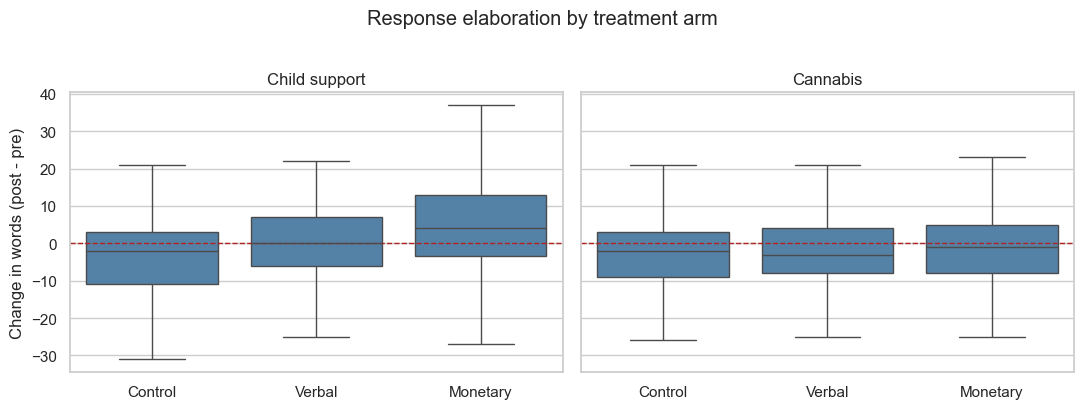

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, topic in zip(axes, ANALYSIS_FILES):
    sub = wide[wide["topic"] == topic].copy()
    sub["Arm"] = sub["group_f"].map(ARM_LABELS)
    sns.boxplot(data=sub, x="Arm", y="change",
                order=[ARM_LABELS[a] for a in ARM_ORDER],
                ax=ax, showfliers=False, color="steelblue")
    ax.axhline(0, color="firebrick", linestyle="--", linewidth=1)
    ax.set_title(topic)
    ax.set_xlabel("")
    ax.set_ylabel("Change in words (post - pre)")
fig.suptitle("Response elaboration by treatment arm", y=1.02)
save_fig("fig_elaboration_by_arm")

## Part 6: Substantive-Response Filter

Separates participation from response substance. The rule-based screen
flags empty, one-word and refusal answers. It does not overwrite the data;
the sensitivity table reports results with and without it.

In [14]:
LOW_INFORMATION_PATTERNS = [
    r"^weiß nicht$", r"^weiss nicht$", r"^keine ahnung$", r"^keine angabe$",
    r"^nichts$", r"^keine idee$", r"^ja$", r"^nein$", r"^egal$", r"^k\. ?a\.?$",
]


def screen_response(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    reasons = []
    if not cleaned:
        reasons.append("empty")
    if len(tokens) <= 1:
        reasons.append("single_token")
    if any(re.match(p, cleaned) for p in LOW_INFORMATION_PATTERNS):
        reasons.append("refusal")
    return pd.Series({"rule_flagged": bool(reasons), "rule_reason": ",".join(reasons)})


screen = length[length["answered"]].copy()
screen = pd.concat([screen, screen["text"].apply(screen_response)], axis=1)
screen["rule_substantive"] = ~screen["rule_flagged"]

print(screen.groupby(["topic", "wave"])
      .agg(answered=("answered", "sum"),
           substantive=("rule_substantive", "sum"),
           pct=("rule_substantive", lambda x: round(100 * x.mean(), 1)))
      .reset_index().to_string(index=False))

        topic wave  answered  substantive  pct
     Cannabis post       510          499 97.8
     Cannabis  pre       481          476 99.0
Child support post       503          496 98.6
Child support  pre       408          398 97.5


In [15]:
sens_rows = []
for label, frame in [("All answered", screen),
                     ("Rule-substantive", screen[screen["rule_substantive"]])]:
    w = (frame.pivot_table(index=["topic", "pid"], columns="wave", values="n_words")
         .dropna().reset_index())
    for topic, sub in w.groupby("topic"):
        t, p = ttest_rel(sub["post"], sub["pre"])
        sens_rows.append({"Topic": topic, "Sample": label, "N": len(sub),
                          "Change": (sub["post"] - sub["pre"]).mean(),
                          "t": t, "p": p})

substantive_sensitivity = (pd.DataFrame(sens_rows).round(3)
                           .sort_values(["Topic", "Sample"]))
print("\nPaired change with and without the filter:")
print(substantive_sensitivity.to_string(index=False))
write_latex_table(substantive_sensitivity, "tab_substantive_sensitivity",
                  caption="Response length: sensitivity to the low-information filter")


Paired change with and without the filter:
        Topic           Sample   N  Change      t     p
     Cannabis     All answered 460  -3.135 -4.088 0.000
     Cannabis Rule-substantive 451  -2.989 -3.878 0.000
Child support     All answered 383   0.593  0.542 0.588
Child support Rule-substantive 375   0.403  0.364 0.716


,Topic,Sample,N,Change,t,p
0,Cannabis,All answered,460,-3.135,-4.088,0.000
2,Cannabis,Rule-substantive,451,-2.989,-3.878,0.000
1,Child support,All answered,383,0.593,0.542,0.588
3,Child support,Rule-substantive,375,0.403,0.364,0.716


## Part 7: Validation Sample

Exports a stratified sample for manual coding. The zero-shot classifier
assigns labels without task-specific training, and its accuracy on German
survey text is unknown until it is checked against human judgement.

Run this cell early, code the `m_*` columns by hand, and save the result as
`validation_sample_aspect_coded.csv`. Agreement is computed in Part 10b,
once the classifier has produced scores to compare against.

In [17]:
# Tier 1: generic frames, identical across topics (Semetko & Valkenburg, 2000).
GENERIC_FRAMES = {
    "Verantwortung": "Die Verantwortung für das Problem oder seine Lösung wird "
                     "der Politik, dem Staat oder einer bestimmten Gruppe zugeschrieben.",
    "Konflikt": "Es wird ein Konflikt oder eine Meinungsverschiedenheit zwischen "
                "Parteien, Gruppen oder Personen betont.",
    "Betroffenheit": "Es werden persönliche Betroffenheit, Einzelschicksale oder "
                     "Gefühle geschildert.",
    "Wirtschaftlichkeit": "Es geht um Kosten, Nutzen oder wirtschaftliche Folgen.",
    "Moral": "Es wird moralisch oder mit Bezug auf Werte und Gerechtigkeit argumentiert.",
}

# Tier 2: issue-specific, from the substance of each legislative debate.
ISSUE_ASPECTS = {
    "Child support": {
        "Armutsbekaempfung": "Es geht darum, Kinderarmut zu verringern und Familien "
                             "mit geringem Einkommen zu unterstützen.",
        "Buerokratie": "Es geht um Bürokratie, Antragstellung oder den Zugang zur Leistung.",
        "Bildungschancen": "Es geht um Bildungschancen und die Zukunft von Kindern.",
        "Finanzierung": "Es geht um die Finanzierung aus Steuermitteln und die "
                        "Belastung des Haushalts.",
        "Umsetzung": "Es geht um die konkrete politische Umsetzung und deren Mängel.",
    },
    "Cannabis": {
        "Jugendschutz": "Es geht um Jugendschutz und Prävention.",
        "Kriminalitaet": "Es geht um Kriminalität, Schwarzmarkt oder Strafverfolgung.",
        "Gesundheit": "Es geht um gesundheitliche Risiken oder Chancen des Konsums.",
        "Freiheit": "Es geht um persönliche Freiheit und Selbstbestimmung.",
        "Regulierung": "Es geht um staatliche Regulierung, Kontrolle und Abgaberegeln.",
    },
}

# Stance: a separate construct, not an aspect.
STANCE_LABELS = {
    "pro": "Der Text spricht sich für das Vorhaben aus.",
    "contra": "Der Text spricht sich gegen das Vorhaben aus.",
    "ambivalent": "Der Text wägt ab oder bleibt unentschieden.",
}

ASPECT_TOPICS = list(ISSUE_ASPECTS)
LABEL_KINDS = ["generic", "issue", "stance"]



In [18]:
VALIDATION_PATH = os.path.join(OUT_DIR, "validation_sample.csv")
N_VALIDATION = 60  # per stratum: topic x wave


sample = (screen.assign(stratum=screen["topic"] + "__" + screen["wave"])
            .groupby("stratum", group_keys=False)
            .apply(lambda f: f.sample(n=min(N_VALIDATION, len(f)),
                                    random_state=RANDOM_STATE),
                    include_groups=False))
sample = sample[["topic", "pid", "wave", "text", "n_words"]].copy()

# One column per label, coded 1/0. Issue columns only apply to their own
# topic and stay empty for the other; stance is single-label and is coded
# in one column instead.
for name in GENERIC_FRAMES:
    sample[f"m_generic__{name}"] = ""
for topic, labels in ISSUE_ASPECTS.items():
    for name in labels:
        sample[f"m_issue__{name}"] = ""
sample["m_stance"] = ""   # one of: pro / contra / ambivalent

sample.to_csv(VALIDATION_PATH, index=False)
print(f"Exported {len(sample)} responses with "
        f"{len(GENERIC_FRAMES)} generic + "
        f"{sum(len(v) for v in ISSUE_ASPECTS.values())} issue columns.")
print("Code 1/0 in the m_* columns and m_stance as pro/contra/ambivalent, "
        "then re-run the next cell.")

Exported 240 responses with 5 generic + 10 issue columns.
Code 1/0 in the m_* columns and m_stance as pro/contra/ambivalent, then re-run the next cell.


## Part 8: Aspect Scheme (measurement check)

The label scheme below was built to classify what participants write about,
using generic frames (Semetko & Valkenburg, 2000) and issue-specific
aspects. It is retained because the validation in Part 10 is reported as a
result: the scheme could not be applied reliably, and that is worth
documenting rather than discarding.

Stance is kept on a separate axis, since a position is not a theme.

In [19]:


def label_set_for(topic, kind):
    """Generic frames and stance are shared across topics; issue aspects are not."""
    if kind == "generic":
        return GENERIC_FRAMES
    if kind == "stance":
        return STANCE_LABELS
    return ISSUE_ASPECTS[topic]


def score_columns(topic, kind):
    return [f"{kind}__{name}" for name in label_set_for(topic, kind)]

## Part 9: Local Classification

Two natural-language-inference models, both small enough to run on a laptop
and both cached locally after the first download. Nothing is sent to an
external service at inference time, which matters given the data-protection
commitments in Section 3.10.

| Role | Model | Basis |
|---|---|---|
| German | `Sahajtomar/German_Zeroshot` | GBERT-large (deepset), fine-tuned on German-language NLI |
| Multilingual | `MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7` | mDeBERTa-v3-base, fine-tuned on XNLI plus a multilingual NLI set covering 27 languages |

The German model leads and the multilingual one serves as a check. Running
both turns model choice from an arbitrary decision into a measurable one:
Kuang et al. (2025) report that zero-shot frame detection varies
substantially across datasets, so agreement between two architectures is
itself a diagnostic. Using an NLI model for this task follows Jumle et al.
(2024) and Kuang et al. (2025); including a German-specific model addresses
the concern Rieger et al. (2024) raise about English-trained models applied
to German text.

**Take the benchmark figures from the current model cards** rather than
from secondary sources, and cite them with an access date.

In [20]:
ZS_MODELS = {
    "gbert": "Sahajtomar/German_Zeroshot",
    "mdeberta": "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7",
}
ZS_PRIMARY_MODEL = "gbert"
ZS_CHECK_MODEL = "mdeberta"

ZS_THRESHOLDS = [0.40, 0.50, 0.60]
ZS_PRIMARY = 0.50
ZS_BATCH_SIZE = 16

# Labels are already full sentences, so each label is the hypothesis itself.
HYPOTHESIS_TEMPLATE = "{}"

SCORES_PATH = os.path.join(OUT_DIR, "aspect_scores_{model}.csv")

In [21]:
def score_with(model_key):
    """Score every response under all three label sets. Cached per model,
    because the classifier is slow and should not run on every execution."""
    path = SCORES_PATH.format(model=model_key)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"{model_key}: loaded cache ({len(df)} rows)")
        return df

    import torch
    from transformers import pipeline

    if torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = 0
    else:
        device = -1

    clf = pipeline("zero-shot-classification", model=ZS_MODELS[model_key],
                   device=device)
    print(f"{model_key}: {ZS_MODELS[model_key]} on device {device}")

    recs = []
    for topic in ASPECT_TOPICS:
        sub = screen[screen["topic"] == topic].reset_index(drop=True)
        texts = sub["text"].astype(str).tolist()
        rows = [{"model": model_key, "topic": topic, "pid": r["pid"], "wave": r["wave"]}
                for _, r in sub.iterrows()]

        for kind in LABEL_KINDS:
            labels = label_set_for(topic, kind)
            hypotheses, names = list(labels.values()), list(labels.keys())
            hyp_to_name = dict(zip(hypotheses, names))

            # Stance is single-label: the three options are mutually exclusive.
            out = clf(texts, hypotheses, multi_label=(kind != "stance"),
                      hypothesis_template=HYPOTHESIS_TEMPLATE,
                      batch_size=ZS_BATCH_SIZE)
            if isinstance(out, dict):
                out = [out]

            for rec, res in zip(rows, out):
                for hyp, score in zip(res["labels"], res["scores"]):
                    rec[f"{kind}__{hyp_to_name[hyp]}"] = score

        recs.extend(rows)
        print(f"  {topic}: {len(texts)} responses")

    df = pd.DataFrame(recs)
    cols = [c for c in df.columns if "__" in c]
    assert df[cols].notna().any(axis=1).all(), "rows without any score"
    df.to_csv(path, index=False)
    print(f"{model_key}: wrote {len(df)} rows")
    return df


scores_by_model = {k: score_with(k) for k in ZS_MODELS}
aspect_scores = scores_by_model[ZS_PRIMARY_MODEL]

gbert: loaded cache (1902 rows)
mdeberta: loaded cache (1902 rows)


## Part 10: Validation

Three checks. The outcome decides whether the aspect tiers can be used at
all, and it turns out they cannot; see the note at the end of Part 11.

In [22]:
from sklearn.metrics import cohen_kappa_score

merged = scores_by_model[ZS_PRIMARY_MODEL].merge(
    scores_by_model[ZS_CHECK_MODEL], on=["topic", "pid", "wave"],
    suffixes=("_a", "_b"))

agree_rows = []
for col in [c for c in scores_by_model[ZS_PRIMARY_MODEL].columns if "__" in c]:
    ca, cb = f"{col}_a", f"{col}_b"
    if ca not in merged.columns or cb not in merged.columns:
        continue
    d = merged[[ca, cb]].dropna()
    if len(d) < 30:
        continue
    fa = (d[ca] >= ZS_PRIMARY).astype(int)
    fb = (d[cb] >= ZS_PRIMARY).astype(int)
    kind, name = col.split("__", 1)
    agree_rows.append({
        "Tier": kind, "Label": name, "N": len(d),
        "Rate_german": 100 * fa.mean(), "Rate_multiling": 100 * fb.mean(),
        "Agreement": 100 * (fa == fb).mean(),
        "Kappa": cohen_kappa_score(fa, fb) if fa.nunique() > 1 and fb.nunique() > 1
                 else np.nan,
        "r": d[ca].corr(d[cb]),
    })

model_agreement = pd.DataFrame(agree_rows).round(3)
print("Agreement between the German and the multilingual model:")
print(model_agreement.to_string(index=False))
write_latex_table(model_agreement, "tab_model_agreement",
                  caption="Cross-model agreement on label assignment")

Agreement between the German and the multilingual model:
   Tier              Label    N  Rate_german  Rate_multiling  Agreement  Kappa     r
generic      Verantwortung 1902       74.711           1.840     26.393  0.003 0.021
generic      Betroffenheit 1902       91.640          85.279     86.488  0.345 0.450
generic              Moral 1902       81.861          87.171     78.812  0.195 0.254
generic Wirtschaftlichkeit 1902       76.183          53.575     60.147  0.172 0.279
generic           Konflikt 1902       82.913          82.913     75.920  0.150 0.295
  issue       Finanzierung  911       53.568          28.540     57.849  0.182 0.281
  issue        Buerokratie  911       36.004          64.654     57.300  0.211 0.294
  issue  Armutsbekaempfung  911       81.668          65.971     66.740  0.166 0.292
  issue    Bildungschancen  911       72.119          91.658     75.851  0.235 0.474
  issue          Umsetzung  911       35.675          35.016     64.874  0.231 0.347
 stance 

,Tier,Label,N,Rate_german,Rate_multiling,Agreement,Kappa,r
0,generic,Verantwortung,1902,74.711,1.840,26.393,0.003,0.021
1,generic,Betroffenheit,1902,91.640,85.279,86.488,0.345,0.450
2,generic,Moral,1902,81.861,87.171,78.812,0.195,0.254
3,generic,Wirtschaftlichkeit,1902,76.183,53.575,60.147,0.172,0.279
4,generic,Konflikt,1902,82.913,82.913,75.920,0.150,0.295
5,issue,Finanzierung,911,53.568,28.540,57.849,0.182,0.281
6,issue,Buerokratie,911,36.004,64.654,57.300,0.211,0.294
7,issue,Armutsbekaempfung,911,81.668,65.971,66.740,0.166,0.292
8,issue,Bildungschancen,911,72.119,91.658,75.851,0.235,0.474
9,issue,Umsetzung,911,35.675,35.016,64.874,0.231,0.347


### Part 10b: Agreement with manual coding

Compares the primary model against the hand-coded sample from Part 7. The
multi-label tiers get one kappa per label; stance is single-label and is
compared as a categorical choice.

`Manual_pct` and `Model_pct` sit next to kappa deliberately: if the model
assigns a label far more often than the coder does, kappa falls even when
the ranking is sound. That is a threshold problem, addressed in Part 11,
not a failure of the classifier.

In [23]:
CODED_PATH = os.path.join(OUT_DIR, "validation_sample_aspect_coded.csv")
coded = read_text_csv(CODED_PATH)
coded["pid"] = coded["pid"].astype(str)

scored = aspect_scores.copy()
scored["pid"] = scored["pid"].astype(str)
val = coded.merge(scored, on=["topic", "pid", "wave"], how="inner",
                  suffixes=("_m", ""))
print(f"Coded responses matched to scores: {len(val)} of {len(coded)}")

val_rows = []
for topic in ASPECT_TOPICS:
    sub = val[val["topic"] == topic]
    if sub.empty:
        continue

    # Multi-label tiers: one kappa per label.
    for kind in ["generic", "issue"]:
        for name in label_set_for(topic, kind):
            mcol, scol = f"m_{kind}__{name}", f"{kind}__{name}"
            if mcol not in sub.columns or scol not in sub.columns:
                continue
            d = sub[[mcol, scol]].replace("", np.nan).dropna()
            if len(d) < 20:
                continue
            manual = d[mcol].astype(float).astype(int)
            model = (d[scol] >= ZS_PRIMARY).astype(int)
            val_rows.append({
                "Topic": topic, "Tier": kind, "Label": name, "N": len(d),
                "Manual_pct": 100 * manual.mean(),
                "Model_pct": 100 * model.mean(),
                "Agreement": 100 * (manual == model).mean(),
                "Kappa": cohen_kappa_score(manual, model)
                         if manual.nunique() > 1 and model.nunique() > 1 else np.nan,
            })

    # Stance is single-label: the model's choice is its highest-scoring option.
    stance_cols = [f"stance__{k}" for k in STANCE_LABELS]
    if "m_stance" in sub.columns and all(c in sub.columns for c in stance_cols):
        d = sub[["m_stance"] + stance_cols].replace("", np.nan).dropna()
        if len(d) >= 20:
            manual = d["m_stance"].str.strip().str.lower()
            model = d[stance_cols].idxmax(axis=1).str.replace("stance__", "",
                                                              regex=False)
            val_rows.append({
                "Topic": topic, "Tier": "stance", "Label": "pro/contra/ambivalent",
                "N": len(d),
                "Manual_pct": np.nan, "Model_pct": np.nan,
                "Agreement": 100 * (manual == model).mean(),
                "Kappa": cohen_kappa_score(manual, model),
            })

validation = pd.DataFrame(val_rows).round(3)
print(validation.to_string(index=False))
write_latex_table(validation, "tab_classifier_validation",
                  caption="Agreement between classifier and manual coding")

for tier, sub in validation.groupby("Tier"):
    k = sub["Kappa"].dropna()
    if len(k):
        print(f"{tier}: mean kappa {k.mean():.3f}, "
              f"{(k >= .60).sum()} of {len(k)} labels at kappa >= .60")

  validation_sample_aspect_coded.csv: separator ',', 240 rows x 21 columns
Coded responses matched to scores: 240 of 240
        Topic    Tier                 Label   N  Manual_pct  Model_pct  Agreement  Kappa
Child support generic         Verantwortung 120      12.500     80.000     27.500  0.000
Child support generic              Konflikt 120       2.500     79.167     23.333  0.013
Child support generic         Betroffenheit 120      14.167     90.833     18.333 -0.030
Child support generic    Wirtschaftlichkeit 120      30.000     74.167     37.500 -0.047
Child support generic                 Moral 120       6.667     83.333     21.667  0.007
Child support   issue     Armutsbekaempfung 120      22.500     80.000     40.833  0.110
Child support   issue           Buerokratie 120       8.333     35.000     65.000  0.067
Child support   issue       Bildungschancen 120      14.167     69.167     41.667  0.085
Child support   issue          Finanzierung 120       9.167     47.500     51.

In [24]:
coded

,topic,pid,wave,text,n_words,m_generic__Verantwortung,m_generic__Konflikt,m_generic__Betroffenheit,m_generic__Wirtschaftlichkeit,m_generic__Moral,m_issue__Armutsbekaempfung,m_issue__Buerokratie,m_issue__Bildungschancen,m_issue__Finanzierung,m_issue__Umsetzung,m_issue__Jugendschutz,m_issue__Kriminalitaet,m_issue__Gesundheit,m_issue__Freiheit,m_issue__Regulierung,m_stance
0,Cannabis,310472966664,post,"Ich finde die Legalisierung nicht korrekt, wei...",26.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,contra
1,Cannabis,292249837296,post,Keine,1.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,ambivalent
2,Cannabis,340646687532,post,"Halte ich für bedenklich, da ich Cannabis für ...",18.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,ambivalent
3,Cannabis,292037520960,post,Letztlich kann man den Konsum nicht verhindert...,34.0,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,ambivalent
4,Cannabis,282839092380,post,Mit der Legalisierung entzieht man einem große...,13.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,ambivalent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,Child support,292439852496,pre,"Ist mir egal, sehe den Vorteil nicht, es gibt ...",12.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,ambivalent
236,Child support,273971922264,pre,Weil es den Kindern ein menschenwürdiges Leben...,8.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,ambivalent
237,Child support,317303528148,pre,ich habe keine Kinder und deshalb habe ich auc...,12.0,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,ambivalent
238,Child support,340634619720,pre,Im Prinzip wird doch einfach nur der Name geän...,73.0,1,0,0,1,0,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,ambivalent


### Part 10c: External validation via stance

The seven-point attitude item measures stance directly, so it is an
external criterion that requires no manual coding. A model that cannot
recover stance from these texts should not be trusted on aspects either.

This is a stronger check than Part 10b, because it compares the classifier
against a measured variable rather than against a second judgement of the
same kind. The manual coding remains necessary for the aspect tiers, where
no external criterion exists.

In [25]:
# Higher values mean a more pro-reform text; the attitude item runs
# 1 = should not be introduced to 7 = should be introduced.
stance_rows = []
for model_key, df in scores_by_model.items():
    if "stance__pro" not in df.columns:
        continue
    pre = df[df["wave"] == "pre"].copy()
    pre["pid"] = pre["pid"].astype(str)
    pre["stance_score"] = pre["stance__pro"] - pre["stance__contra"]

    for topic in ASPECT_TOPICS:
        att = frames[topic][["pid", "att_baseline"]].copy()
        att["pid"] = att["pid"].astype(str)
        d = (pre[pre["topic"] == topic]
             .merge(att, on="pid", how="inner")
             .dropna(subset=["stance_score", "att_baseline"]))
        if len(d) < 30:
            continue
        stance_rows.append({
            "Model": model_key, "Topic": topic, "N": len(d),
            "r": d["stance_score"].corr(d["att_baseline"]),
        })

stance_validation = pd.DataFrame(stance_rows).round(3)
print("Classifier stance against the measured attitude item (pre-wave):")
print(stance_validation.to_string(index=False))
write_latex_table(stance_validation, "tab_stance_validation",
                  caption="External validation: classifier stance vs. attitude item")

if not stance_validation.empty and stance_validation["r"].abs().max() < 0.25:
    print("\nStance recovery is weak. Parts 11 and 12 are reported as a "
          "measurement exercise, not as findings.")

Classifier stance against the measured attitude item (pre-wave):
   Model         Topic   N     r
   gbert Child support 408 0.436
   gbert      Cannabis 481 0.650
mdeberta Child support 408 0.443
mdeberta      Cannabis 481 0.630


## Part 11: Threshold Sensitivity and Conclusion

The 0.50 cut is arbitrary, so the assignment is recomputed at 0.40 and
0.60. If over-assignment persists across all three, the problem is the
formulation of the hypotheses rather than the cut.

**Outcome of the validation.** Agreement with manual coding is at chance
level for both aspect tiers (kappa between -0.05 and 0.11), driven by
systematic over-assignment: the classifier marks a label present in 65 to
91 per cent of responses where the human coder marks 2 to 30 per cent.
Raising the threshold does not resolve it. The aspect analysis is therefore
not carried further, and the pre/post shift models are dropped.

Stance is the exception and is reported: it recovers the measured attitude
item at r = .44 (child support) and r = .65 (cannabis), nearly identically
under both models. The failure is therefore specific to extracting thematic
focus from short free-text answers, not a general failure of the model on
German survey text.

In [26]:
thresh_rows = []
for thr in ZS_THRESHOLDS:
    for topic in ASPECT_TOPICS:
        for kind in ["generic", "issue"]:
            cols = [c for c in score_columns(topic, kind)
                    if c in aspect_scores.columns]
            sub = aspect_scores[aspect_scores["topic"] == topic]
            flags = sub[cols] >= thr
            thresh_rows.append({
                "Topic": topic, "Tier": kind, "Threshold": thr,
                "MeanLabels": flags.sum(axis=1).mean(),
                "PctNone": 100 * (flags.sum(axis=1) == 0).mean(),
                "PctAll": 100 * (flags.sum(axis=1) == len(cols)).mean(),
            })

threshold_sensitivity = pd.DataFrame(thresh_rows).round(2)
print("Label assignment by threshold:")
print(threshold_sensitivity.to_string(index=False))
write_latex_table(threshold_sensitivity, "tab_threshold_sensitivity", digits=2,
                  caption="Sensitivity of label assignment to the score threshold")

Label assignment by threshold:
        Topic    Tier  Threshold  MeanLabels  PctNone  PctAll
Child support generic        0.4        4.41     0.55   61.80
Child support   issue        0.4        3.28     1.43   18.22
     Cannabis generic        0.4        4.37     1.92   63.57
     Cannabis   issue        0.4        2.88     3.33    7.57
Child support generic        0.5        4.05     0.88   45.88
Child support   issue        0.5        2.79     4.28    8.78
     Cannabis generic        0.5        4.09     2.32   50.96
     Cannabis   issue        0.5        2.36     5.05    3.83
Child support generic        0.6        3.57     1.98   28.65
Child support   issue        0.6        2.31     6.92    3.84
     Cannabis generic        0.6        3.56     3.73   29.97
     Cannabis   issue        0.6        1.87     9.99    1.72


,Topic,Tier,Threshold,MeanLabels,PctNone,PctAll
0,Child support,generic,0.4,4.41,0.55,61.80
1,Child support,issue,0.4,3.28,1.43,18.22
2,Cannabis,generic,0.4,4.37,1.92,63.57
3,Cannabis,issue,0.4,2.88,3.33,7.57
4,Child support,generic,0.5,4.05,0.88,45.88
5,Child support,issue,0.5,2.79,4.28,8.78
6,Cannabis,generic,0.5,4.09,2.32,50.96
7,Cannabis,issue,0.5,2.36,5.05,3.83
8,Child support,generic,0.6,3.57,1.98,28.65
9,Child support,issue,0.6,2.31,6.92,3.84


In [27]:
print("Tables:")
print(sorted(f for f in os.listdir(TAB_DIR) if f.endswith(".tex")))
print("\nFigures:")
print(sorted(os.listdir(FIG_DIR)))

Tables:
['tab_aspect_by_arm.tex', 'tab_aspect_shifts.tex', 'tab_classifier_validation.tex', 'tab_elaboration.tex', 'tab_elaboration_by_arm.tex', 'tab_elaboration_model.tex', 'tab_elaboration_uptake.tex', 'tab_generic_frames_by_topic.tex', 'tab_model_agreement.tex', 'tab_participation_model.tex', 'tab_response_rates.tex', 'tab_stance_validation.tex', 'tab_substantive_sensitivity.tex', 'tab_threshold_sensitivity.tex']

Figures:
['fig_elaboration_by_arm.png', 'fig_generic_frame_shifts.png']
